# OculoMesh: Exploratory Data Analysis
**Visualizing Cryptographically Entangled Biometric Graphs**

Welcome to the EDA notebook for the OculoMesh project. Traditional biometric datasets consist of 2D images (pixels). This dataset is different. Here, we have already extracted the human iris into **Topological Graphs** (nodes and edges) and entangled them with **SHA-256 Cryptographic Chaff** to create a cancelable, privacy-preserving biometric template.

In this notebook, we will:
1. Analyze the macro-statistics of the graph dataset.
2. Visually plot a pristine biometric graph.
3. Simulate and visualize environmental degradation (occlusion and blur) to demonstrate topological redundancy.

In [6]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.4 MB/s eta 0:00:0000:01


In [7]:
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx
import copy
from torch_geometric.utils import subgraph

# Styling for plots
plt.style.use('dark_background')
colors = ['#00e676', '#ff3d00', '#00b0ff'] # Cyberpunk/Hacker aesthetic colors

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


In [8]:
# Load the 50% Cryptographic Noise Dataset
DATA_PATH = "/kaggle/input/datasets/mohitrajsinhjadeja/gnn-iris-graph/iris_graphs_50.pt"
raw_data = torch.load(DATA_PATH, weights_only=False)

# Calculate basic statistics
num_graphs = len(raw_data)
avg_nodes = sum([g.num_nodes for g in raw_data]) / num_graphs
avg_edges = sum([g.num_edges for g in raw_data]) / num_graphs
unique_subjects = len(set([g.y.item() for g in raw_data]))

print(f"📊 Dataset Overview:")
print(f"---------------------------------")
print(f"Total Biometric Graphs: {num_graphs}")
print(f"Total Unique Subjects:  {unique_subjects}")
print(f"Average Nodes per Graph: {avg_nodes:.1f}")
print(f"Average Edges per Graph: {avg_edges:.1f}")
print(f"Node Feature Dimension:  {raw_data[0].num_node_features}")

📊 Dataset Overview:
---------------------------------
Total Biometric Graphs: 2608
Total Unique Subjects:  249
Average Nodes per Graph: 193.2
Average Edges per Graph: 1163.7
Node Feature Dimension:  3


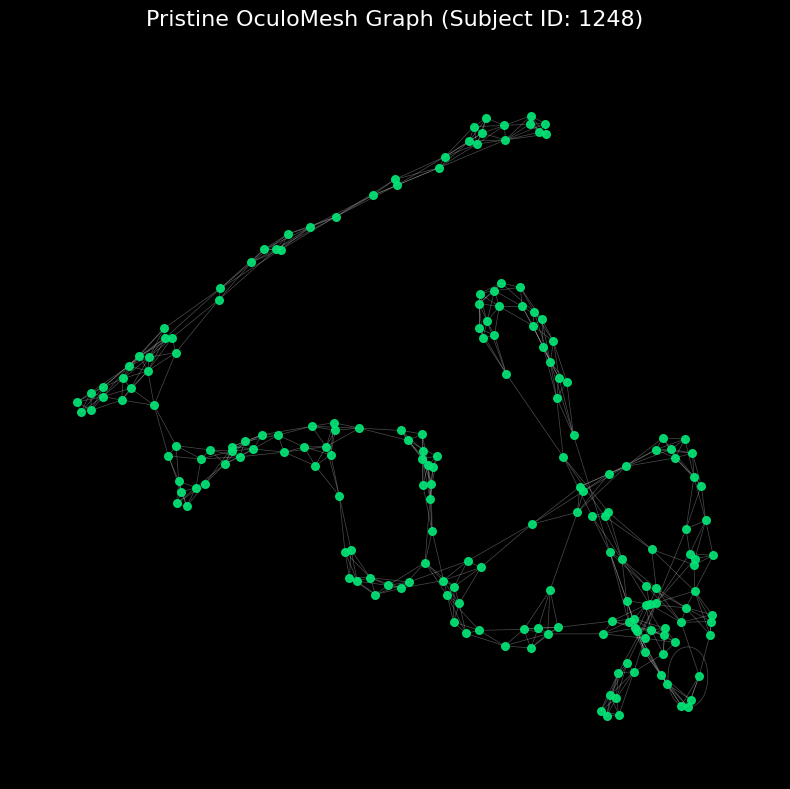

In [9]:
def plot_graph(data, title, color_hex):
    """Converts a PyTorch Geometric graph to NetworkX and plots it."""
    G = to_networkx(data, to_undirected=True)
    
    plt.figure(figsize=(8, 8))
    plt.title(title, fontsize=16, pad=20)
    
    # We use a spring layout to naturally space out the nodes
    pos = nx.spring_layout(G, seed=42)
    
    nx.draw_networkx_nodes(G, pos, node_size=30, node_color=color_hex, alpha=0.9)
    nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.3, edge_color="white")
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize the very first graph in the dataset
sample_graph = raw_data[0]
plot_graph(sample_graph, f"Pristine OculoMesh Graph (Subject ID: {sample_graph.y.item()})", colors[0])

###  Simulating Environmental Degradation
To prove the noise-invariance of the Graph Convolutional approach, we will simulate physical occlusion (e.g., shadows or eyelashes) by aggressively dropping nodes from the graph to see if the macro-structure survives.

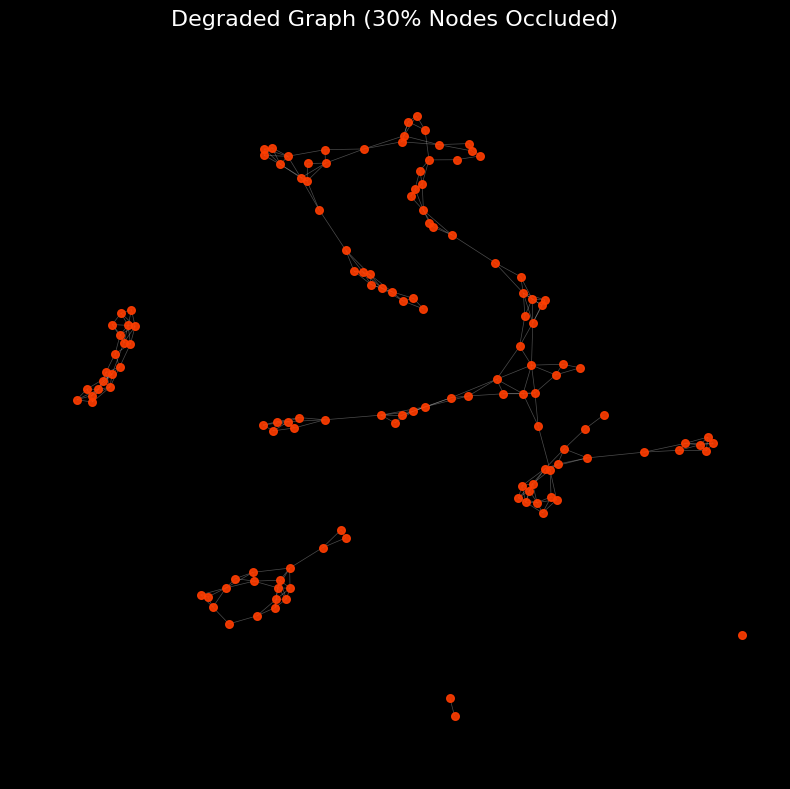

Original Nodes: 198 | Surviving Nodes: 137
Notice how the macro-topological structure remains intact despite massive data loss.


In [10]:
def degrade_graph(data, drop_rate=0.30):
    """Simulates occlusion by dropping random nodes."""
    degraded = copy.deepcopy(data)
    num_nodes = degraded.x.size(0)
    
    # Drop random nodes based on the drop rate
    keep_mask = torch.rand(num_nodes) > drop_rate
    
    # Safely filter edges
    edge_index, _ = subgraph(
        keep_mask, 
        degraded.edge_index, 
        relabel_nodes=True, 
        num_nodes=num_nodes
    )
    
    degraded.x = degraded.x[keep_mask]
    degraded.edge_index = edge_index
    return degraded

# Create a severely degraded version of the same graph (Level 3 Stress)
degraded_graph = degrade_graph(sample_graph, drop_rate=0.30)

plot_graph(degraded_graph, "Degraded Graph (30% Nodes Occluded)", colors[1])

print(f"Original Nodes: {sample_graph.num_nodes} | Surviving Nodes: {degraded_graph.num_nodes}")
print("Notice how the macro-topological structure remains intact despite massive data loss.")